# Pydlem Model Run with Static Inputs Example 2
This notebook provides an example of using meteorologic and reservoir geometry data to run the DLEM model.

### Outline
1. Import packages and modules
2. Import Required Inputs 
3. Initialize and Run Model
4. Plot the Results

#### 1. Import packages and modules

In [ ]:
# file paths and directory
import os
from pathlib import Path
import warnings

# math and data wrangling
import pandas as pd
import geopandas as gpd
import xarray as xr
import numpy as np

# model functions and classes
pydlem_dir = Path(r'C:\Users\CND905\Downloaded_Programs\pydlem')
os.chdir(pydlem_dir)
import dlem

# for this example
import matplotlib.pyplot as plt

Initializing daily lake evaporation model...


#### 2. Import Required Inputs 

We will import the required input data first just to show it. 

In [2]:
inputdat = xr.load_dataset(r'C:\Users\CND905\Downloaded_Programs\pydlem\examples\example_data\Example1_static_inputs.nc')
inputdat

<xarray.Dataset> Size: 326kB
Dimensions:    (time: 366, location: 11)
Coordinates:
    lat        (location) float64 88B 44.54 44.56 44.57 ... 44.5 44.53 44.55
    lon        (location) float64 88B -107.2 -107.2 -107.2 ... -107.2 -107.2
    elev       (location) float64 88B 2.638e+03 2.517e+03 ... 2.618e+03
    area       (location) float64 88B 0.05123 1.258 0.02779 ... 0.6691 0.1195
  * location   (location) <U9 396B '71772797' '71772129' ... '71772619'
  * time       (time) datetime64[ns] 3kB 2024-01-01 2024-01-02 ... 2024-12-31
Data variables:
    max_temp   (time, location) float64 32kB 273.4 273.7 274.0 ... 264.4 265.0
    min_temp   (time, location) float64 32kB 262.7 263.0 263.4 ... 254.1 256.7
    solrad     (time, location) float64 32kB 76.3 76.2 76.1 ... 51.2 50.65 50.1
    wind_dir   (time, location) float64 32kB 308.0 308.0 308.0 ... 305.0 305.0
    wind_vel   (time, location) float64 32kB 3.6 3.6 3.6 3.3 ... 4.2 4.05 3.9
    vpd        (time, location) float64 32kB 0.2 0.21 0.22 ... 0.04 0.05 0.06
    precip     (time, location) float64 32kB 0.0 0.0 0.0 0.0 ... 2.1 0.0 0.0 0.0
    LakeArea   (time, location) float64 32kB 0.051 1.258 0.028 ... 0.6691 0.12
    LakeDepth  (time, location) float64 32kB 5.078 10.17 6.429 ... 8.519 5.75
    ftch_len   (time, location) float64 32kB 159.3 3.929e+03 ... 2.044e+03 366.5
Attributes:
    featureType:  timeSeries

#### 3. Initialize and Run Model
 To run the model, we will load the input data into the class to initialize it. Then we will run the model. 

In [3]:
dlem_mod = dlem.CreateModel()
dlem_mod.load_datafile(r'C:\Users\CND905\Downloaded_Programs\pydlem\examples\example_data\Example1_static_inputs.nc')
dlem_mod.run_model(start='2016-01-01', end='2024-12-31', sim_ice=True)

Estimating ice cover...


100%|██████████| 477/477 [00:00<00:00, 506.12it/s]


An xarray.Dataset is made with the three model outputs, evap, ice precence and lags. We can also calculate the net evaporation (evap - precip) and add those results to the output xarray.Dataset

In [4]:
# calculate net evaporation and create dataarray
net_evap = xr.DataArray(dlem_mod.outputs['evap'].values - inputdat['precip'].values, coords=dlem_mod.outputs.coords, attrs={'standard_name': 'Net Evaporation Rate', 'units': 'mm/day'})
net_evap.name = 'net_evap'
dlem_mod.outputs = xr.merge([dlem_mod.outputs, net_evap])

In [5]:
dlem_mod.outputs

<xarray.Dataset> Size: 133kB
Dimensions:   (time: 366, location: 11)
Coordinates:
    lat       (location) float64 88B 44.54 44.56 44.57 ... 44.5 44.53 44.55
    lon       (location) float64 88B -107.2 -107.2 -107.2 ... -107.2 -107.2
    elev      (location) float64 88B 2.638e+03 2.517e+03 ... 2.664e+03 2.618e+03
    area      (location) float64 88B 0.05123 1.258 0.02779 ... 0.6691 0.1195
  * location  (location) <U9 396B '71772797' '71772129' ... '71772619'
  * time      (time) datetime64[ns] 3kB 2024-01-01 2024-01-02 ... 2024-12-31
Data variables:
    evap      (time, location) float64 32kB 0.0 0.0 0.0 0.0 ... 0.0 0.5213 0.0
    ice       (time, location) float64 32kB 1.0 1.0 1.0 1.0 ... 1.0 1.0 0.0 1.0
    lags      (time, location) float64 32kB 0.0 0.0 0.0 0.0 ... -1.0 -1.0 -1.0
    net_evap  (time, location) float64 32kB 0.0 0.0 0.0 0.0 ... 0.0 0.5213 0.0

4. Plot the Results

C:\Users\CND905\AppData\Local\Temp\ipykernel_5572\2049932905.py:4: MatplotlibDeprecationWarning: The plot_date function was deprecated in Matplotlib 3.9 and will be removed in 3.11. Use plot instead.
  ax.plot_date(dlem_mod.outputs.time, dlem_mod.outputs.evap.values[:,loc], 'black')
C:\Users\CND905\AppData\Local\Temp\ipykernel_5572\2049932905.py:5: MatplotlibDeprecationWarning: The plot_date function was deprecated in Matplotlib 3.9 and will be removed in 3.11. Use plot instead.
  ax.plot_date(dlem_mod.outputs.time, dlem_mod.outputs.ice.values[:,loc], 'blue')
C:\Users\CND905\AppData\Local\Temp\ipykernel_5572\2049932905.py:6: MatplotlibDeprecationWarning: The plot_date function was deprecated in Matplotlib 3.9 and will be removed in 3.11. Use plot instead.
  ax.plot_date(dlem_mod.outputs.time, dlem_mod.outputs.lags.values[:,loc], 'red')


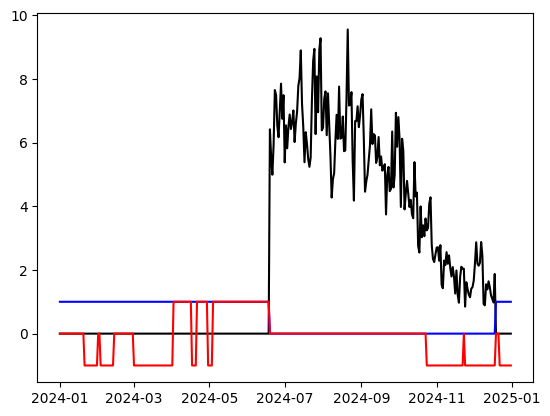

In [6]:
loc = 10

ax = plt.axes()
ax.plot_date(dlem_mod.outputs.time, dlem_mod.outputs.evap.values[:,loc], 'black')
ax.plot_date(dlem_mod.outputs.time, dlem_mod.outputs.ice.values[:,loc], 'blue')
ax.plot_date(dlem_mod.outputs.time, dlem_mod.outputs.lags.values[:,loc], 'red')

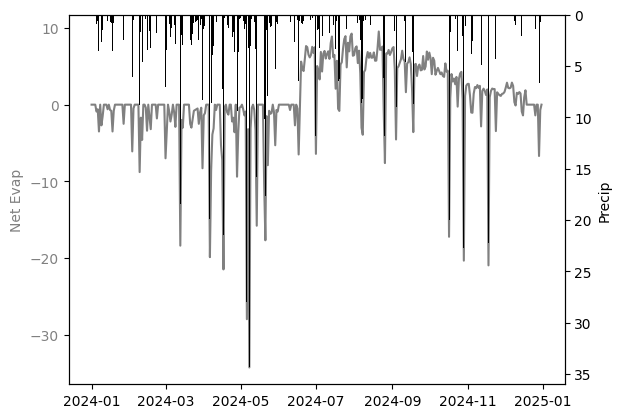

In [ ]:
fig, ax1 = plt.subplots()



# line plot
ax1.plot(dlem_mod.outputs.time.values, dlem_mod.outputs.net_evap.values[:,loc], color='gray', label='Net Evap')
ax1.set_ylabel('Net Evap', color='gray')
ax1.tick_params(axis='y', labelcolor='gray')

# bar plot
ax2 = ax1.twinx()
ax2.bar(dlem_mod.outputs.time.values, inputdat.precip.values[:,loc], color='black', label='Precip')
ax2.set_xlabel('Time')
ax2.set_ylabel('Precip', color='black')
ax2.tick_params(axis='y', labelcolor='black')
ax2.invert_yaxis()